In [49]:
# In[1]

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from datetime import datetime

sns.set_theme(style='whitegrid')

# Adjust display options if desired
pd.options.display.max_rows = 50
pd.options.display.max_columns = 20


In [50]:
# In[2]

# 2.1 Load the JSON
with open('github-data.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

members = data['members']           # List of member dicts
repositories = data['repositories'] # List of repo dicts
issues_by_repo = data['issues']     # { repo_name: [issues], ... }
issues_events_by_repo = data['issues_events'] # { repo_name: [issue_events], ... }
commits_by_repo = data['commits']   # { repo_name: [commits], ... }
timeline_events_by_repo = data['timeline_events']    # List of event dicts
relationship_mapping_by_repo = data['relationship_mapping'] # List of relationship dicts

# 2.2 Convert members to a DataFrame
df_members = pd.DataFrame(members)

# 2.3 Quick inspection
display(df_members.head())


,id,node_id,login,public_repos,followers,following,created_at,active
0,108633030,U_kgDOBnmbxg,Adleey,2,0,0,2022-07-03T21:05:41Z,True
1,134176815,U_kgDOB_9gLw,AugustoLiberato,11,4,8,2023-05-20T23:51:44Z,True
2,95926022,U_kgDOBbe3Bg,Benjamin-Nobrega,6,2,3,2021-12-10T14:58:06Z,True
3,12025215,MDQ6VXNlcjEyMDI1MjE1,danrleypereira,51,42,33,2015-04-20T00:48:52Z,True
4,49729245,MDQ6VXNlcjQ5NzI5MjQ1,devmarcosvinicius,17,55,44,2019-04-17T17:31:01Z,True


In [51]:
# In[3]

def parse_github_date(date_str):
    # e.g. '2022-07-03T21:05:41Z'
    return datetime.strptime(date_str, '%Y-%m-%dT%H:%M:%SZ')

now = datetime.now()

# Compute account age (days) from created_at
df_members['account_age_days'] = df_members['created_at'].apply(
    lambda d: (now - parse_github_date(d)).days
)

# Define a maturity score TODO: Adjust weights
df_members['maturity_score'] = (
    0.5 * df_members['account_age_days']
    + 10 * df_members['public_repos']
    + 15 * df_members['followers']
)

# Classify new vs. established
df_members['status'] = df_members.apply(
    lambda row: 'new' if (
        row['account_age_days'] < 365
        or (row['public_repos'] < 10
        and row['followers'] < 10)
    ) else 'established',
    axis=1
)

df_members.head()


,id,node_id,login,public_repos,followers,following,created_at,active,account_age_days,maturity_score,status
0,108633030,U_kgDOBnmbxg,Adleey,2,0,0,2022-07-03T21:05:41Z,True,957,498.5,new
1,134176815,U_kgDOB_9gLw,AugustoLiberato,11,4,8,2023-05-20T23:51:44Z,True,636,488.0,established
2,95926022,U_kgDOBbe3Bg,Benjamin-Nobrega,6,2,3,2021-12-10T14:58:06Z,True,1162,671.0,new
3,12025215,MDQ6VXNlcjEyMDI1MjE1,danrleypereira,51,42,33,2015-04-20T00:48:52Z,True,3589,2934.5,established
4,49729245,MDQ6VXNlcjQ5NzI5MjQ1,devmarcosvinicius,17,55,44,2019-04-17T17:31:01Z,True,2130,2060.0,established


In [52]:
# In[4]

all_issues = []

for repo_name, issues_list in issues_by_repo.items():
    for issue in issues_list:
        issue_dict = {
            'repo': repo_name,
            'issue_number': issue['number'],
            'title': issue['title'],
            'state': issue['state'],
            'creator': issue['user']['login'],
            'assignee': issue['assignee']['login'] if issue['assignee'] is not None else None,
            'created_at': issue['created_at'],
            'updated_at': issue['updated_at'],
            'pull_request': (issue['pull_request'] is not None),
            'timeline_url': issue.get('timeline_url', None),
        }
        all_issues.append(issue_dict)

df_issues = pd.DataFrame(all_issues)
display(df_issues.head())


,repo,issue_number,title,state,creator,assignee,created_at,updated_at,pull_request,timeline_url
0,python-services,30,[Get] - Todos as Salas Disponíveis em um certo...,open,GuiMcs00,None,2024-12-21T01:14:40Z,2024-12-21T01:14:40Z,False,https://api.github.com/repos/LabTechUDF/python...
1,python-services,29,Processar Ofertas e Salvar na Coleção de Reservas,open,GuiMcs00,None,2024-12-19T18:08:57Z,2024-12-19T18:08:57Z,False,https://api.github.com/repos/LabTechUDF/python...
2,python-services,27,bugfix: send link is not using auth service,open,danrleypereira,josue-oliveiraa,2024-11-22T17:25:04Z,2024-12-04T20:02:40Z,False,https://api.github.com/repos/LabTechUDF/python...
3,python-services,23,22-requisição-aos-recursos-compartilhados,open,Gabriel-br07,Gabriel-br07,2024-11-04T14:56:30Z,2024-12-26T01:14:40Z,True,https://api.github.com/repos/LabTechUDF/python...
4,python-services,22,Requisição aos Recursos Compartilhados,open,GuiMcs00,Gabriel-br07,2024-10-29T00:28:15Z,2024-12-12T18:28:49Z,False,https://api.github.com/repos/LabTechUDF/python...


In [54]:
# In[4.5]

# 4.5.1 Extract issue events
all_issue_events = []
for repo_name, events_list in issues_events_by_repo.items():
    for event in events_list:
        event_dict = {
            'repo': repo_name,
            'issue_number': event['issue']['number'],
            'actor': event['actor']['login'],
            'event': event['event'],
            'created_at': event['created_at'],
        }
        all_issue_events.append(event_dict)

df_issue_events = pd.DataFrame(all_issue_events)
display(df_issue_events.head())
display(df_issue_events['event'].value_counts())

,repo,issue_number,actor,event,created_at
0,python-services,23,Gabriel-br07,review_requested,2024-12-26T01:14:40Z
1,python-services,29,GuiMcs00,labeled,2024-12-19T18:08:57Z
2,python-services,23,Gabriel-br07,review_requested,2024-12-13T19:18:58Z
3,python-services,28,danrleypereira,closed,2024-12-08T04:28:15Z
4,python-services,28,danrleypereira,merged,2024-12-08T04:28:15Z


event
assigned                  56
closed                    53
review_requested          38
merged                    33
referenced                31
connected                 22
head_ref_deleted          22
renamed                   18
labeled                   17
unassigned                10
subscribed                 4
mentioned                  4
base_ref_changed           3
head_ref_force_pushed      2
disconnected               2
head_ref_restored          1
review_request_removed     1
Name: count, dtype: int64

In [55]:
# In[5]

all_timeline_events = []

for repo_name, issues in timeline_events_by_repo.items():
    for issue_number, events in issues.items():
        for evt in events:
            # Extract the created_at timestamp based on event type
            if evt.get("event") == "committed":
                # For commit events, try to get the timestamp from author or committer
                created_at = evt.get("author", {}).get("date") or evt.get("committer", {}).get("date")
            elif evt.get("event") == "reviewed":
                # For review events, use 'submitted_at' if available
                created_at = evt.get("submitted_at")
            else:
                created_at = evt.get("created_at")
            
            # Extract the actor's login. Some events use "actor", others might use "user"
            actor = evt.get("actor", {}).get("login") or evt.get("user", {}).get("login", "")
            
            all_timeline_events.append({
                'repo': repo_name,
                'issue_number': issue_number,
                'event': evt.get('event', ''),
                'created_at': created_at,
                'actor': actor
            })

# Create the dataframe from the normalized list of events
df_timeline = pd.DataFrame(all_timeline_events)
display(df_timeline.head())
display(df_timeline['event'].value_counts())
display(df_timeline['event'].unique())
display(df_timeline['repo'].unique())



,repo,issue_number,event,created_at,actor
0,python-services,29,labeled,2024-12-19T18:08:57Z,GuiMcs00
1,python-services,27,assigned,2024-11-22T17:25:04Z,danrleypereira
2,python-services,27,commented,2024-12-04T00:22:35Z,josue-oliveiraa
3,python-services,27,commented,2024-12-04T00:25:02Z,josue-oliveiraa
4,python-services,23,committed,2024-11-04T14:53:42Z,


event
committed                 87
assigned                  13
labeled                   11
review_requested           9
commented                  8
connected                  6
reviewed                   5
renamed                    3
subscribed                 2
mentioned                  2
unassigned                 1
cross-referenced           1
review_request_removed     1
Name: count, dtype: int64

array(['labeled', 'assigned', 'commented', 'committed', 'connected',
       'review_requested', 'reviewed', 'unassigned', 'renamed',
       'review_request_removed', 'cross-referenced', 'mentioned',
       'subscribed'], dtype=object)

array(['python-services', 'interfaces-usuario', 'teachers-allocation',
       'research', 'shared-resources'], dtype=object)

In [41]:
# In[6]

# We'll define "contributions" = #issues created + #issues assigned + #PRs authored + #commits + #PRs reviewed + #comments
contributions_per_user = {}

for repo_name, issues_list in issues_by_repo.items():
    for issue_data in issues_list:
        creator = issue_data['user']['login']
        assignee = issue_data['assignee']['login'] if issue_data['assignee'] is not None else None
        if creator not in contributions_per_user:
            contributions_per_user[creator] = {'issues-created': 0, 'issues-assigned': 0, 'commits': 0, 'prs-authored': 0, 'prs-reviewed': 0, 'comments': 0 }
        if assignee is not None and assignee not in contributions_per_user:
            contributions_per_user[assignee] = {'issues-created': 0, 'issues-assigned': 0, 'commits': 0, 'prs-authored': 0, 'prs-reviewed': 0, 'comments': 0 }
        if issue_data['pull_request'] is not None:
            contributions_per_user[creator]['prs-authored'] += 1
        elif assignee is not None and creator != assignee:
            contributions_per_user[creator]['issues-created'] += 1
            contributions_per_user[assignee]['issues-assigned'] += 1
        else:
            contributions_per_user[creator]['issues-created'] += 1

df_members['issues-created'] = df_members['login'].apply(
    lambda login: contributions_per_user.get(login, {}).get('issues-created', 0)
)
df_members['issues-assigned'] = df_members['login'].apply(
    lambda login: contributions_per_user.get(login, {}).get('issues-assigned', 0)
)
df_members['prs-authored'] = df_members['login'].apply(
    lambda login: contributions_per_user.get(login, {}).get('prs-authored', 0)
)

df_members.head()


,id,node_id,login,public_repos,followers,following,created_at,active,account_age_days,maturity_score,status,issues,prs,issues-created,issues-assigned,prs-authored
0,108633030,U_kgDOBnmbxg,Adleey,2,0,0,2022-07-03T21:05:41Z,True,957,498.5,new,0,0,0,0,0
1,134176815,U_kgDOB_9gLw,AugustoLiberato,11,4,8,2023-05-20T23:51:44Z,True,636,488.0,established,0,0,0,0,0
2,95926022,U_kgDOBbe3Bg,Benjamin-Nobrega,6,2,3,2021-12-10T14:58:06Z,True,1162,671.0,new,0,0,0,0,0
3,12025215,MDQ6VXNlcjEyMDI1MjE1,danrleypereira,51,42,33,2015-04-20T00:48:52Z,True,3589,2934.5,established,0,0,9,1,3
4,49729245,MDQ6VXNlcjQ5NzI5MjQ1,devmarcosvinicius,17,55,44,2019-04-17T17:31:01Z,True,2130,2060.0,established,0,0,0,0,0


In [44]:
# [6.1]

# create a array to committed events
commits = df_timeline[df_timeline['event'] == 'committed']
# get the number of commits per user
commits_per_user = commits['actor'].value_counts().to_dict()
# add the number of commits to the df_members
df_members['commits'] = df_members['login'].apply(lambda login: commits_per_user.get(login, 0))

# create a array to reviewed events
reviews = df_timeline[df_timeline['event'] == 'reviewed']
# get the number of reviews per user
reviews_per_user = reviews['actor'].value_counts().to_dict()
# add the number of reviews to the df_members
df_members['prs-reviewed'] = df_members['login'].apply(lambda login: reviews_per_user.get(login, 0))

# create a array to commented events
comments = df_timeline[df_timeline['event'] == 'commented']
# get the number of comments per user
comments_per_user = comments['actor'].value_counts().to_dict()
# add the number of comments to the df_members
df_members['comments'] = df_members['login'].apply(lambda login: comments_per_user.get(login, 0))


df_members['total_contribs'] = df_members['issues-created'] + df_members['issues-assigned'] + df_members['commits'] + df_members['prs-authored'] + df_members['prs-reviewed'] + df_members['comments']
df_members['has_contributed'] = df_members['total_contribs'] > 0

df_members.head()

,id,node_id,login,public_repos,followers,following,created_at,active,account_age_days,maturity_score,...,issues,prs,issues-created,issues-assigned,prs-authored,commits,prs-reviewed,comments,total_contribs,has_contributed
0,108633030,U_kgDOBnmbxg,Adleey,2,0,0,2022-07-03T21:05:41Z,True,957,498.5,...,0,0,0,0,0,0,0,0,0,False
1,134176815,U_kgDOB_9gLw,AugustoLiberato,11,4,8,2023-05-20T23:51:44Z,True,636,488.0,...,0,0,0,0,0,0,0,0,0,False
2,95926022,U_kgDOBbe3Bg,Benjamin-Nobrega,6,2,3,2021-12-10T14:58:06Z,True,1162,671.0,...,0,0,0,0,0,0,0,0,0,False
3,12025215,MDQ6VXNlcjEyMDI1MjE1,danrleypereira,51,42,33,2015-04-20T00:48:52Z,True,3589,2934.5,...,0,0,9,1,3,0,1,2,16,True
4,49729245,MDQ6VXNlcjQ5NzI5MjQ1,devmarcosvinicius,17,55,44,2019-04-17T17:31:01Z,True,2130,2060.0,...,0,0,0,0,0,0,0,0,0,False


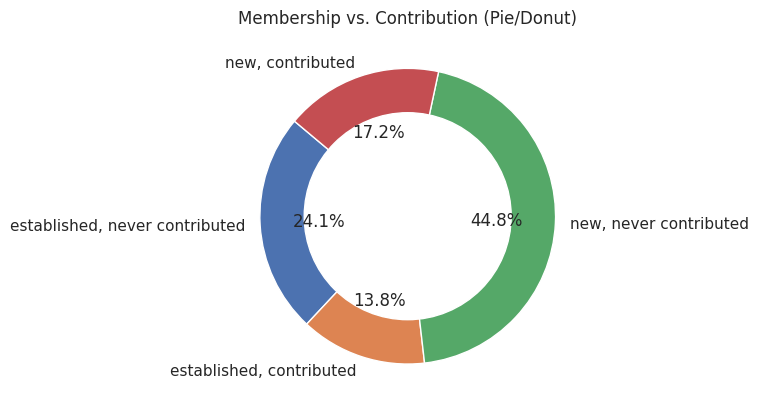

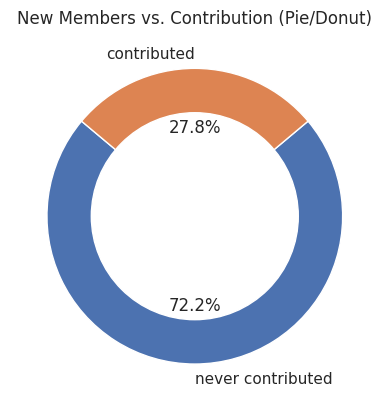

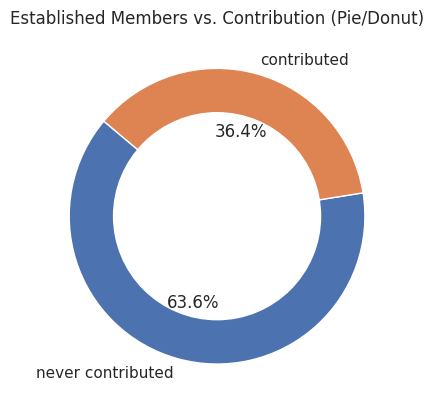

In [46]:
# In[7]

# Existing code
contrib_groups = df_members.groupby(['status', 'has_contributed']).size().reset_index(name='count')

labels = []
sizes = []
for row in contrib_groups.itertuples():
    s = row.status
    c = 'contributed' if row.has_contributed else 'never contributed'
    labels.append(f"{s}, {c}")
    sizes.append(row.count)

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)
plt.title('Membership vs. Contribution (Pie/Donut)')
plt.show()

# New code for "new" members
new_members = df_members[df_members['status'] == 'new']
new_contrib_groups = new_members.groupby(['has_contributed']).size().reset_index(name='count')

new_labels = ['contributed' if row.has_contributed else 'never contributed' for row in new_contrib_groups.itertuples()]
new_sizes = new_contrib_groups['count'].tolist()

fig, ax = plt.subplots()
ax.pie(new_sizes, labels=new_labels, autopct='%1.1f%%', startangle=140)
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)
plt.title('New Members vs. Contribution (Pie/Donut)')
plt.show()

# New code for "established" members
established_members = df_members[df_members['status'] == 'established']
established_contrib_groups = established_members.groupby(['has_contributed']).size().reset_index(name='count')

established_labels = ['contributed' if row.has_contributed else 'never contributed' for row in established_contrib_groups.itertuples()]
established_sizes = established_contrib_groups['count'].tolist()

fig, ax = plt.subplots()
ax.pie(established_sizes, labels=established_labels, autopct='%1.1f%%', startangle=140)
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)
plt.title('Established Members vs. Contribution (Pie/Donut)')
plt.show()


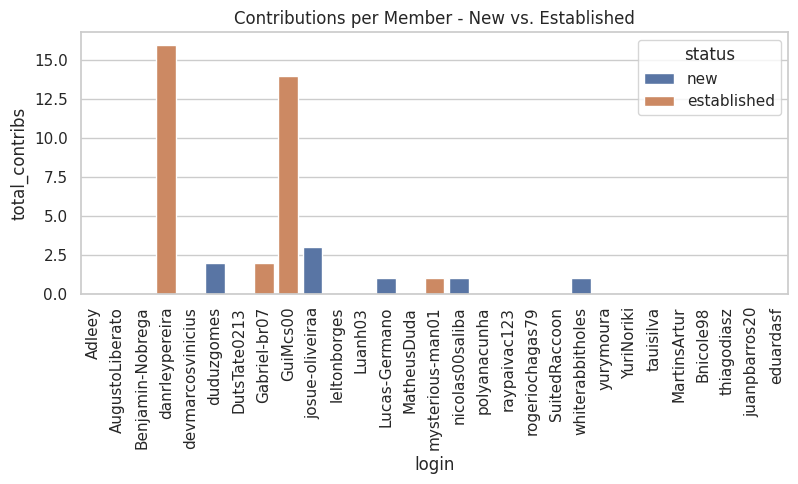

In [47]:
# In[8]

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_members, x='login', y='total_contribs', hue='status', dodge=False)
plt.xticks(rotation=90)
plt.title('Contributions per Member - New vs. Established')
plt.tight_layout()
plt.show()


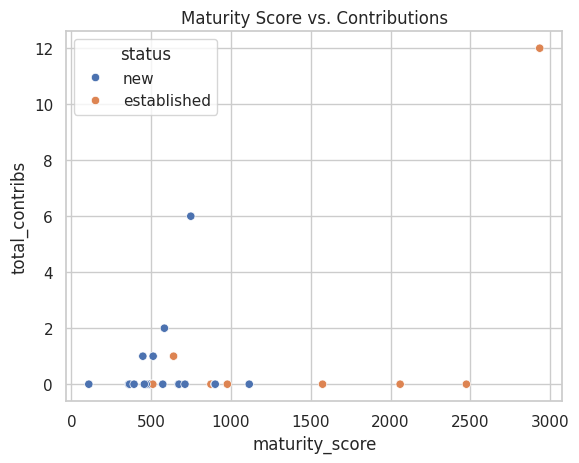

In [11]:
# In[9]

fig, ax = plt.subplots()
sns.scatterplot(data=df_members, x='maturity_score', y='total_contribs', hue='status')
plt.title('Maturity Score vs. Contributions')
plt.show()


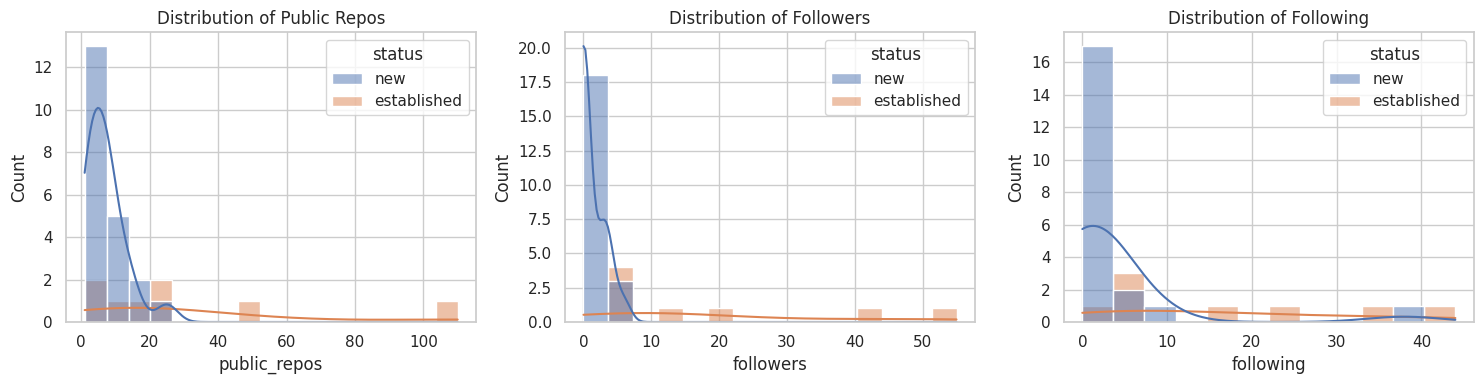

In [12]:
# In[10]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(data=df_members, x='public_repos', hue='status', kde=True, ax=axes[0])
axes[0].set_title('Distribution of Public Repos')

sns.histplot(data=df_members, x='followers', hue='status', kde=True, ax=axes[1])
axes[1].set_title('Distribution of Followers')

sns.histplot(data=df_members, x='following', hue='status', kde=True, ax=axes[2])
axes[2].set_title('Distribution of Following')

plt.tight_layout()
plt.show()


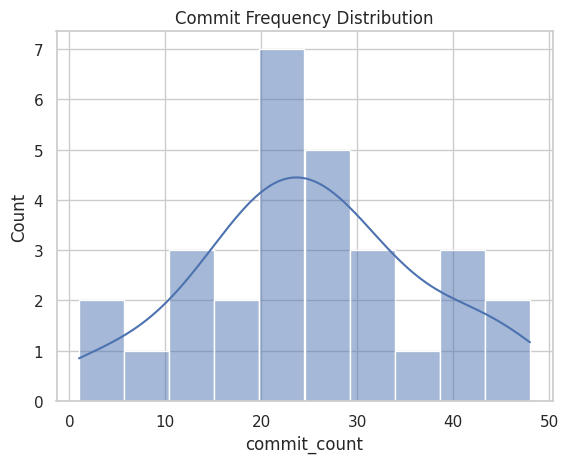

In [13]:
# In[11]

# Suppose we've added df_members['commit_count'] from some data source
# Just a placeholder example:
if 'commit_count' not in df_members.columns:
    df_members['commit_count'] = np.random.randint(0, 50, len(df_members))

sns.histplot(data=df_members, x='commit_count', bins=10, kde=True)
plt.title('Commit Frequency Distribution')
plt.show()


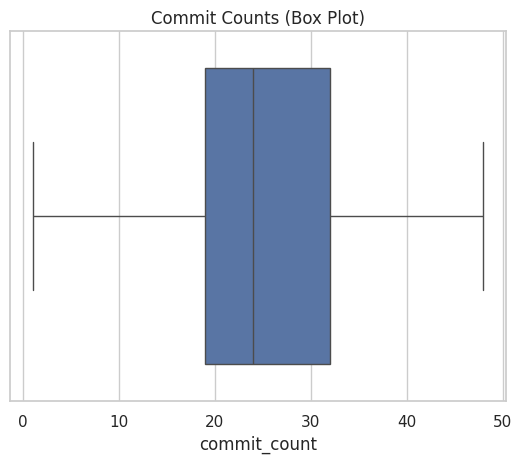

In [14]:
# In[12]

sns.boxplot(x=df_members['commit_count'])
plt.title('Commit Counts (Box Plot)')
plt.show()


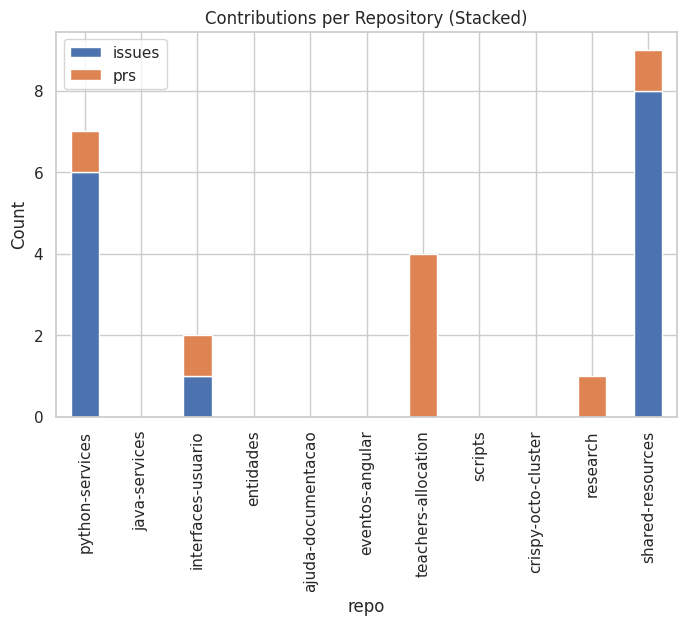

In [15]:
# In[13]

repo_stats = []
for r, issues_list in issues_by_repo.items():
    total_issues = sum(1 for i in issues_list if i['pull_request'] is None)
    total_prs = sum(1 for i in issues_list if i['pull_request'] is not None)
    # total_commits = ... if you have commit data
    repo_stats.append({'repo': r, 'issues': total_issues, 'prs': total_prs})

df_repo_stats = pd.DataFrame(repo_stats).set_index('repo')
df_repo_stats[['issues', 'prs']].plot(
    kind='bar', stacked=True, figsize=(8,5), title='Contributions per Repository (Stacked)'
)
plt.ylabel('Count')
plt.show()


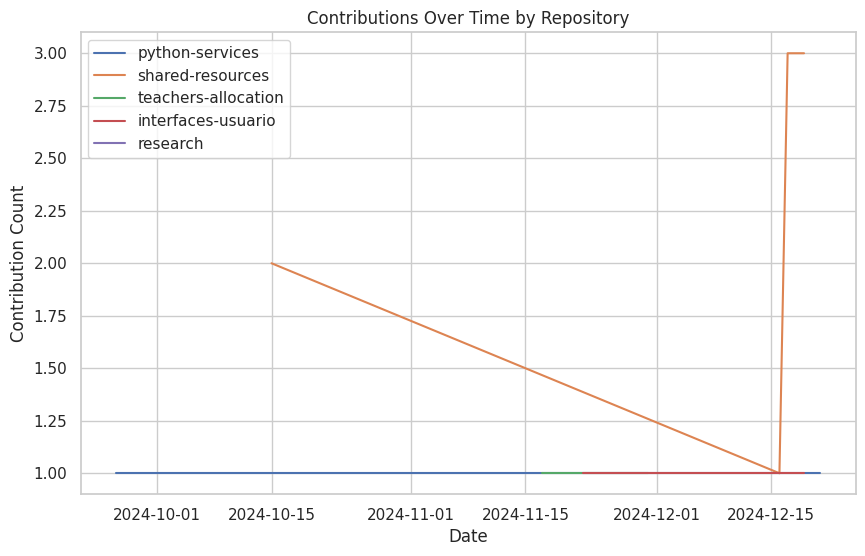

In [16]:
# In[14]

all_issue_events = []
for r, issues_list in issues_by_repo.items():
    for issue in issues_list:
        created_date = datetime.strptime(issue['created_at'], '%Y-%m-%dT%H:%M:%SZ')
        is_pr = issue['pull_request'] is not None
        all_issue_events.append({
            'repo': r,
            'created_at': created_date,
            'type': 'PR' if is_pr else 'Issue'
        })

df_all_issues = pd.DataFrame(all_issue_events)
df_all_issues['date'] = df_all_issues['created_at'].dt.date

daily_counts = df_all_issues.groupby(['date','repo'])['type'].count().reset_index(name='count')

fig, ax = plt.subplots(figsize=(10, 6))
for repo_name in daily_counts['repo'].unique():
    subset = daily_counts[daily_counts['repo'] == repo_name]
    ax.plot(subset['date'], subset['count'], label=repo_name)

ax.set_title('Contributions Over Time by Repository')
ax.set_xlabel('Date')
ax.set_ylabel('Contribution Count')
ax.legend()
plt.show()


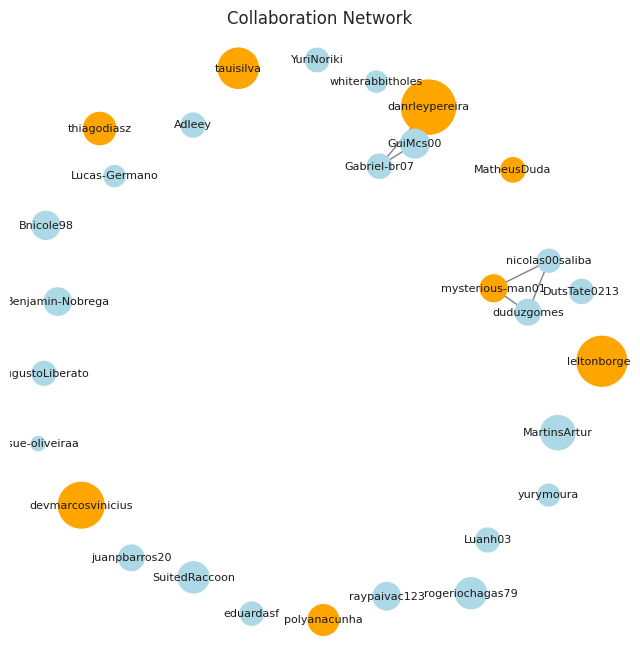

In [17]:
# In[15]

G = nx.Graph()

# Add nodes (one per member)
for m in df_members['login']:
    G.add_node(m)

# For each repo, link members who both contributed
for repo_name, issues_list in issues_by_repo.items():
    contributors = { i['user']['login'] for i in issues_list }
    c_list = list(contributors)
    for i in range(len(c_list)):
        for j in range(i+1, len(c_list)):
            u, v = c_list[i], c_list[j]
            if not G.has_edge(u, v):
                G.add_edge(u, v, weight=1)
            else:
                G[u][v]['weight'] += 1

pos = nx.spring_layout(G, k=0.5, iterations=50)

node_sizes = []
node_colors = []
for node in G.nodes():
    row = df_members[df_members['login'] == node]
    if not row.empty:
        node_sizes.append(row['maturity_score'].values[0]*0.5 + 50)
        node_colors.append('lightblue' if row['status'].values[0] == 'new' else 'orange')
    else:
        node_sizes.append(50)
        node_colors.append('gray')

plt.figure(figsize=(8,8))
nx.draw_networkx(
    G, pos,
    node_color=node_colors,
    node_size=node_sizes,
    edge_color='gray',
    with_labels=True,
    font_size=8
)
plt.title('Collaboration Network')
plt.axis('off')
plt.show()


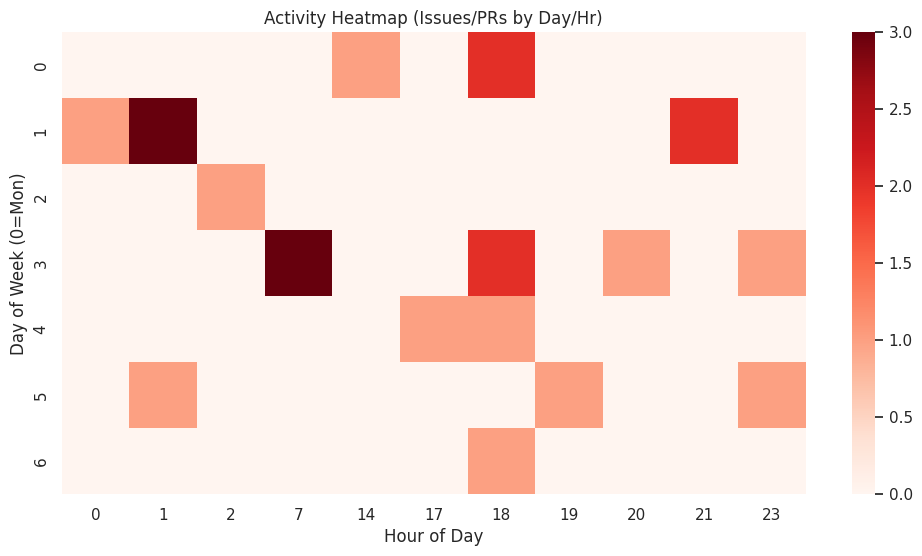

In [18]:
# In[16]

# Reuse df_all_issues from above or build a new one
df_all_issues['day_of_week'] = df_all_issues['created_at'].dt.dayofweek  # Monday=0
df_all_issues['hour_of_day'] = df_all_issues['created_at'].dt.hour

heatmap_data = df_all_issues.groupby(['day_of_week', 'hour_of_day']).size().reset_index(name='count')
heatmap_pivot = heatmap_data.pivot(index='day_of_week', columns='hour_of_day', values='count').fillna(0)

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_pivot, cmap='Reds')
plt.title('Activity Heatmap (Issues/PRs by Day/Hr)')
plt.ylabel('Day of Week (0=Mon)')
plt.xlabel('Hour of Day')
plt.show()


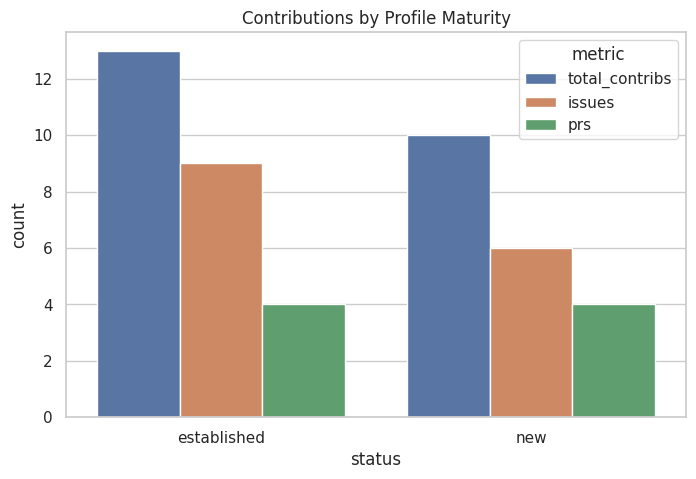

In [19]:
# In[17]

# Summarize total issues & PRs by status
summary_df = df_members.groupby('status').agg({
    'total_contribs': 'sum',
    'issues': 'sum',
    'prs': 'sum'
}).reset_index()

melted = summary_df.melt(id_vars='status', var_name='metric', value_name='count')

plt.figure(figsize=(8,5))
sns.barplot(data=melted, x='status', y='count', hue='metric')
plt.title('Contributions by Profile Maturity')
plt.show()
